In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("Imports OK ✓")

C:\Users\NRND4649\OpenClassRooms\Projet_7\P7env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK ✓


In [2]:
# ============================================================
# Configuration MLFlow
# ============================================================

# On définit le dossier où MLFlow stockera ses données
mlflow.set_tracking_uri('file:../mlruns')

# On crée une expérience dédiée à ce projet
mlflow.set_experiment('scoring_credit')

print("MLFlow configuré ✓")
print(f"Tracking URI : {mlflow.get_tracking_uri()}")

MLFlow configuré ✓
Tracking URI : file:../mlruns


In [3]:
# ============================================================
# Chargement du dataset préparé et split train/test
# ============================================================
df = pd.read_csv('../data/application_train_prepared.csv')

# Séparation features / cible
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"\nDistribution de y :\n{y.value_counts(normalize=True).round(3)}")

# Split train/test stratifié
# stratify=y garantit que le déséquilibre des classes
# est conservé dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # pour la reproductibilité
    stratify=y            # important avec des classes déséquilibrées !
)

print(f"\nShape X_train : {X_train.shape}")
print(f"Shape X_test  : {X_test.shape}")
print(f"\nDistribution y_train : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribution y_test  : {y_test.value_counts(normalize=True).round(3).to_dict()}")

Shape X : (307511, 254)
Shape y : (307511,)

Distribution de y :
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Shape X_train : (246008, 254)
Shape X_test  : (61503, 254)

Distribution y_train : {0: 0.919, 1: 0.081}
Distribution y_test  : {0: 0.919, 1: 0.081}


In [4]:
# ============================================================
# Score métier
# ============================================================
# Rappel : un FN coûte 10x plus qu'un FP
# FN = mauvais client prédit bon → crédit accordé → perte en capital
# FP = bon client prédit mauvais → crédit refusé → manque à gagner

def score_metier(y_true, y_pred, cout_fn=10, cout_fp=1):
    """
    Calcule le coût métier normalisé d'un modèle de classification.
    
    Paramètres :
    - y_true   : valeurs réelles (0 ou 1)
    - y_pred   : valeurs prédites (0 ou 1)
    - cout_fn  : coût d'un faux négatif (défaut par défaut = 10)
    - cout_fp  : coût d'un faux positif (défaut par défaut = 1)
    
    Retourne :
    - coût normalisé (entre 0 et 1, plus c'est bas mieux c'est)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    cout_total = (fn * cout_fn) + (fp * cout_fp)
    
    # Normalisation : on divise par le pire cas possible
    # (prédire tout le monde comme bon client = tous les défauts sont des FN)
    pire_cas = y_true.sum() * cout_fn
    
    return cout_total / pire_cas


def optimiser_seuil(y_true, y_proba, cout_fn=10, cout_fp=1):
    """
    Trouve le seuil optimal qui minimise le score métier.
    
    Paramètres :
    - y_true  : valeurs réelles
    - y_proba : probabilités prédites pour la classe 1
    
    Retourne :
    - seuil optimal
    - score métier au seuil optimal
    """
    seuils = np.arange(0.01, 0.99, 0.01)
    scores = []
    
    for seuil in seuils:
        y_pred = (y_proba >= seuil).astype(int)
        scores.append(score_metier(y_true, y_pred, cout_fn, cout_fp))
    
    idx_optimal = np.argmin(scores)
    return seuils[idx_optimal], scores[idx_optimal]


In [5]:
# ============================================================
# Baseline - DummyClassifier
# ============================================================
with mlflow.start_run(run_name="baseline_dummy"):
    
    # Modèle qui prédit toujours la classe majoritaire
    dummy = DummyClassifier(strategy='most_frequent', random_state=42)
    dummy.fit(X_train, y_train)
    
    # Prédictions
    y_pred_dummy = dummy.predict(X_test)
    y_proba_dummy = dummy.predict_proba(X_test)[:, 1]
    
    # Métriques
    auc_dummy = roc_auc_score(y_test, y_proba_dummy)
    seuil_dummy, cout_dummy = optimiser_seuil(y_test, y_proba_dummy)
    
    # Log MLFlow
    mlflow.log_metric("auc", auc_dummy)
    mlflow.log_metric("cout_metier", cout_dummy)
    mlflow.log_metric("seuil_optimal", seuil_dummy)
    mlflow.log_param("model", "DummyClassifier")
    mlflow.log_param("strategy", "most_frequent")
    
    print(f"=== Baseline DummyClassifier ===")
    print(f"AUC          : {auc_dummy:.4f}")
    print(f"Coût métier  : {cout_dummy:.4f}")
    print(f"Seuil optimal: {seuil_dummy:.2f}")

=== Baseline DummyClassifier ===
AUC          : 0.5000
Coût métier  : 1.0000
Seuil optimal: 0.01


In [6]:
# ============================================================
# Modèle 1 - Régression Logistique
# ============================================================
from sklearn.linear_model import LogisticRegression

with mlflow.start_run(run_name="logistic_regression"):
    
    lr = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # gère le déséquilibre des classes
        random_state=42,
        n_jobs=-1
    )
    lr.fit(X_train, y_train)
    
    # Prédictions
    y_proba_lr = lr.predict_proba(X_test)[:, 1]
    
    # Métriques
    auc_lr = roc_auc_score(y_test, y_proba_lr)
    seuil_lr, cout_lr = optimiser_seuil(y_test, y_proba_lr)
    
    # Log MLFlow
    mlflow.log_metric("auc", auc_lr)
    mlflow.log_metric("cout_metier", cout_lr)
    mlflow.log_metric("seuil_optimal", seuil_lr)
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.sklearn.log_model(lr, "model")
    
    print(f"=== Régression Logistique ===")
    print(f"AUC          : {auc_lr:.4f}")
    print(f"Coût métier  : {cout_lr:.4f}")
    print(f"Seuil optimal: {seuil_lr:.2f}")

2026/04/16 11:07:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 11:07:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Régression Logistique ===
AUC          : 0.7606
Coût métier  : 0.6517
Seuil optimal: 0.50


In [7]:
# ============================================================
# Modèle 2 - LightGBM
# ============================================================
with mlflow.start_run(run_name="lightgbm_baseline"):
    
    lgbm = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1        # supprime les logs d'entraînement
    )
    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],  # surveille la performance sur le test
    )
    
    # Prédictions
    y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
    
    # Métriques
    auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)
    seuil_lgbm, cout_lgbm = optimiser_seuil(y_test, y_proba_lgbm)
    
    # Log MLFlow
    mlflow.log_metric("auc", auc_lgbm)
    mlflow.log_metric("cout_metier", cout_lgbm)
    mlflow.log_metric("seuil_optimal", seuil_lgbm)
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("num_leaves", 31)
    mlflow.log_param("class_weight", "balanced")
    mlflow.sklearn.log_model(lgbm, "model")
    
    print(f"=== LightGBM baseline ===")
    print(f"AUC          : {auc_lgbm:.4f}")
    print(f"Coût métier  : {cout_lgbm:.4f}")
    print(f"Seuil optimal: {seuil_lgbm:.2f}")

2026/04/16 11:08:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 11:08:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== LightGBM baseline ===
AUC          : 0.7748
Coût métier  : 0.6298
Seuil optimal: 0.48


In [8]:
# ============================================================
# Optimisation LightGBM - GridSearchCV
# ============================================================
from sklearn.model_selection import GridSearchCV

# On définit la grille d'hyperparamètres à tester
param_grid = {
    'n_estimators'  : [300, 500],
    'learning_rate' : [0.05, 0.1],
    'num_leaves'    : [31, 63],
    'min_child_samples': [20, 50],
}

# Modèle de base
lgbm_base = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Cross-validation stratifiée à 5 folds
# stratified = on conserve le ratio des classes dans chaque fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',   # on optimise sur l'AUC
    n_jobs=-1,
    verbose=1            # affiche la progression
)

print("Lancement du GridSearchCV...")
print(f"Nombre de combinaisons à tester : {2*2*2*2} x 5 folds = {2*2*2*2*5} fits")
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur AUC (CV)    : {grid_search.best_score_:.4f}")

Lancement du GridSearchCV...
Nombre de combinaisons à tester : 16 x 5 folds = 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Meilleurs paramètres : {'learning_rate': 0.05, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 31}
Meilleur AUC (CV)    : 0.7706


2026/04/16 11:27:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 11:27:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== LightGBM optimisé ===
AUC test         : 0.7753
AUC CV           : 0.7706
Coût métier      : 0.6248
Seuil optimal    : 0.50


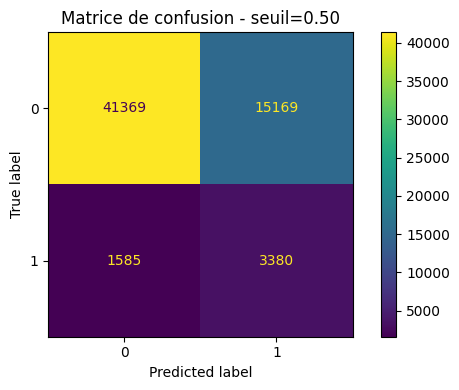

In [9]:
# ============================================================
# Modèle final - LightGBM optimisé
# ============================================================
with mlflow.start_run(run_name="lightgbm_optimized"):
    
    best_params = grid_search.best_params_
    
    lgbm_final = lgb.LGBMClassifier(
        **best_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgbm_final.fit(X_train, y_train)
    
    # Prédictions
    y_proba_final = lgbm_final.predict_proba(X_test)[:, 1]
    
    # Métriques
    auc_final = roc_auc_score(y_test, y_proba_final)
    seuil_final, cout_final = optimiser_seuil(y_test, y_proba_final)
    y_pred_final = (y_proba_final >= seuil_final).astype(int)
    
    # Log MLFlow
    mlflow.log_params(best_params)
    mlflow.log_param("model", "LightGBM_optimized")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("auc", auc_final)
    mlflow.log_metric("cout_metier", cout_final)
    mlflow.log_metric("seuil_optimal", seuil_final)
    mlflow.log_metric("auc_cv", grid_search.best_score_)
    mlflow.sklearn.log_model(lgbm_final, "model")
    
    print(f"=== LightGBM optimisé ===")
    print(f"AUC test         : {auc_final:.4f}")
    print(f"AUC CV           : {grid_search.best_score_:.4f}")
    print(f"Coût métier      : {cout_final:.4f}")
    print(f"Seuil optimal    : {seuil_final:.2f}")
    
    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=ax)
    ax.set_title(f"Matrice de confusion - seuil={seuil_final:.2f}")
    plt.tight_layout()
    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.show()

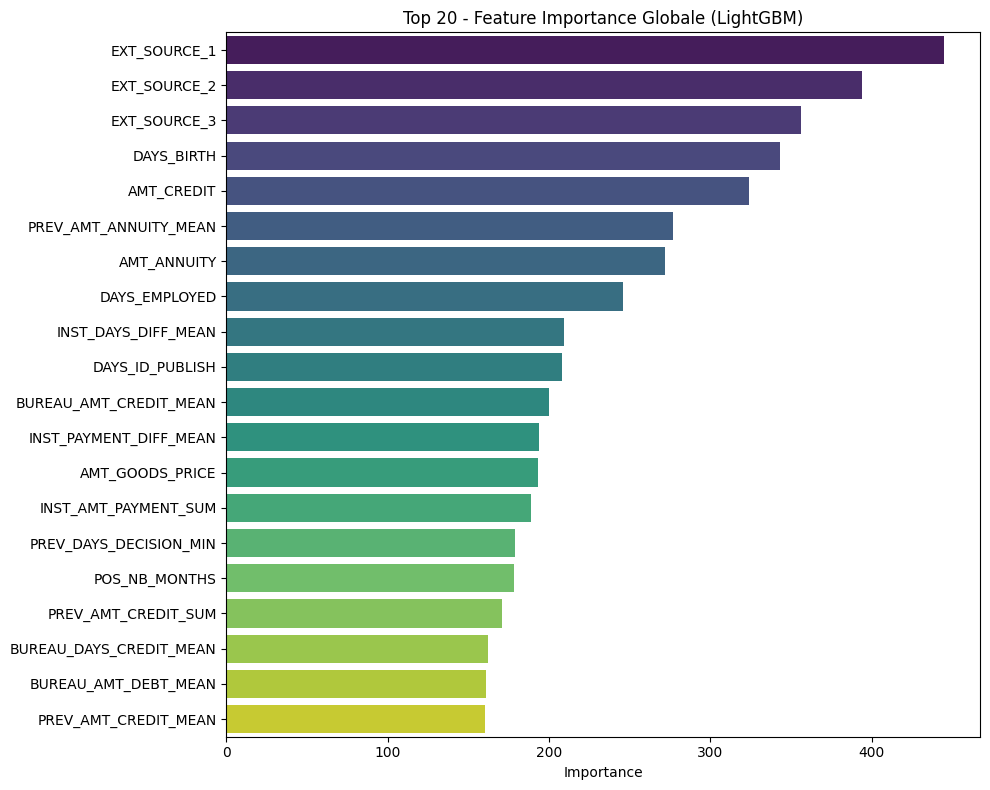


Top 10 features :
              feature  importance
         EXT_SOURCE_1         445
         EXT_SOURCE_2         394
         EXT_SOURCE_3         356
           DAYS_BIRTH         343
           AMT_CREDIT         324
PREV_AMT_ANNUITY_MEAN         277
          AMT_ANNUITY         272
        DAYS_EMPLOYED         246
  INST_DAYS_DIFF_MEAN         209
      DAYS_ID_PUBLISH         208


In [10]:
# ============================================================
# Feature Importance Globale
# ============================================================
import shap

# LightGBM a sa propre feature importance intégrée
# On commence par celle-là car elle est rapide à calculer

feature_importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': lgbm_final.feature_importances_
}).sort_values('importance', ascending=False)

# Top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    x='importance',
    y='feature',
    palette='viridis',
    ax=ax
)
ax.set_title("Top 20 - Feature Importance Globale (LightGBM)")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig('../models/feature_importance_globale.png')
plt.show()

print(f"\nTop 10 features :")
print(feature_importance.head(10).to_string(index=False))

In [16]:
# ============================================================
# Feature Importance Locale - SHAP
# ============================================================
sample_size = 1000
X_sample = X_test.iloc[:sample_size]

explainer = shap.TreeExplainer(lgbm_final)
shap_explanation = explainer(X_sample)

print(f"Shape shap_explanation.values : {shap_explanation.values.shape}")

Shape shap_explanation.values : (1000, 254)


In [17]:
print(f"Shape shap_explanation.values : {shap_explanation.values.shape}")
print(f"Type : {type(shap_explanation.values)}")

Shape shap_explanation.values : (1000, 254)
Type : <class 'numpy.ndarray'>


Shape shap_values : (1000, 254)


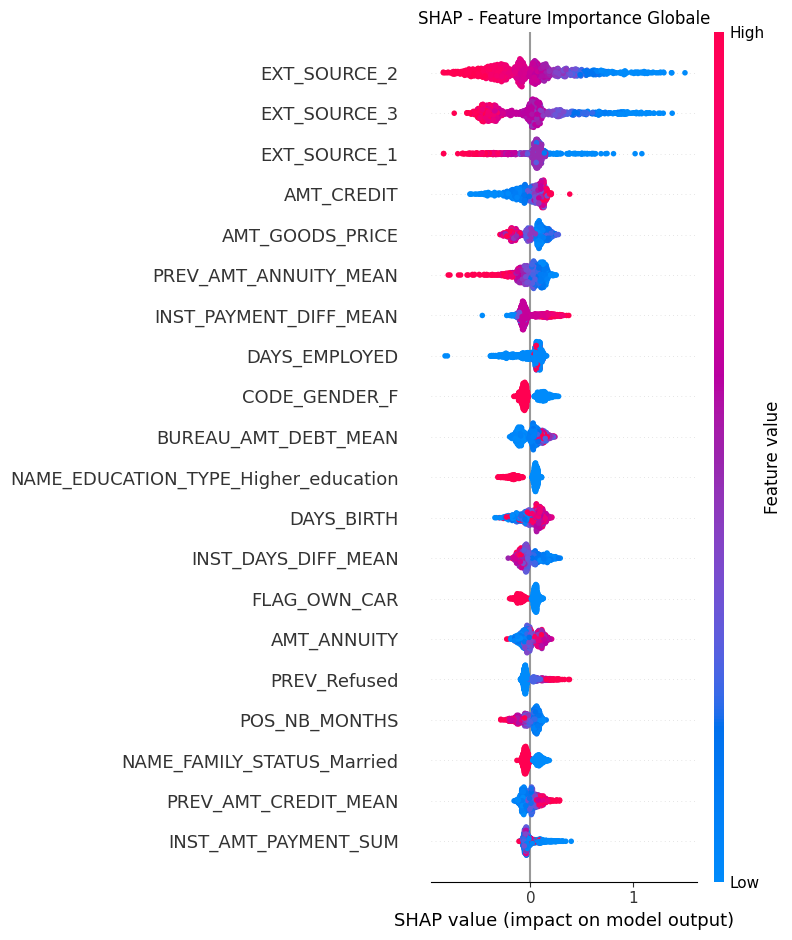

In [18]:
shap_vals = shap_explanation.values
print(f"Shape shap_values : {shap_vals.shape}")

# -- Graphique 1 : Summary plot global --
plt.figure()
shap.summary_plot(
    shap_vals,
    X_sample,
    max_display=20,
    show=False
)
plt.title("SHAP - Feature Importance Globale")
plt.tight_layout()
plt.savefig('../models/shap_summary_global.png')
plt.show()

Probabilité de défaut du client 0 : 0.3581
Décision (seuil=0.5) : ACCORDÉ


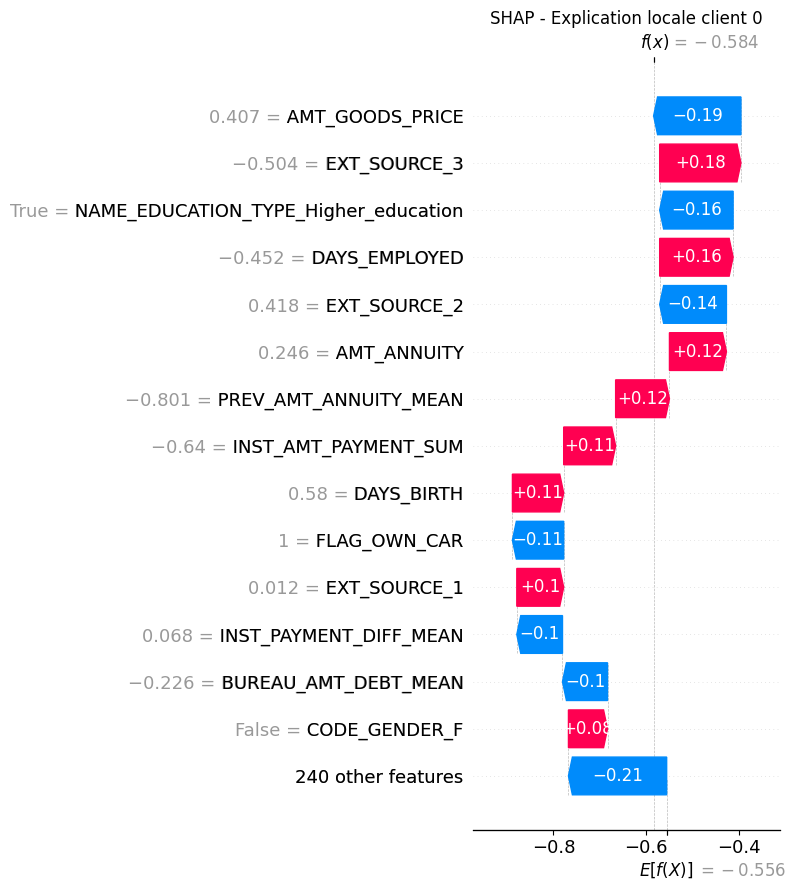

In [19]:
# ============================================================
# Feature Importance Locale - SHAP (un client)
# ============================================================

# On prend le premier client de l'échantillon
client_idx = 0
client = X_sample.iloc[[client_idx]]
proba_client = lgbm_final.predict_proba(client)[0][1]
print(f"Probabilité de défaut du client {client_idx} : {proba_client:.4f}")
print(f"Décision (seuil={seuil_final}) : {'REFUSÉ' if proba_client >= seuil_final else 'ACCORDÉ'}")

# Waterfall plot - montre comment chaque feature
# contribue à la prédiction pour CE client
plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_explanation.values[client_idx],
        base_values=shap_explanation.base_values[client_idx],
        data=X_sample.iloc[client_idx],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP - Explication locale client {client_idx}")
plt.tight_layout()
plt.savefig('../models/shap_local_client.png')
plt.show()

In [20]:
# ============================================================
# Sauvegarde du modèle final sur disque
# ============================================================
import joblib

joblib.dump(lgbm_final, '../models/lgbm_final.pkl')
joblib.dump(seuil_final, '../models/seuil_optimal.pkl')

print("Modèle sauvegardé ✓")
print(f"Seuil optimal sauvegardé : {seuil_final}")

Modèle sauvegardé ✓
Seuil optimal sauvegardé : 0.5


In [21]:
# ============================================================
# Récupération d'un client exemple pour tester l'API
# ============================================================
import json

# On prend le premier client du test set
client_exemple = X_test.iloc[0].to_dict()

# Affichage du JSON à envoyer à l'API
print(json.dumps(client_exemple, indent=2)[:500])  # on affiche juste les 500 premiers caractères
print("\n...")
print(f"\nNombre de features : {len(client_exemple)}")

{
  "NAME_CONTRACT_TYPE": 0,
  "FLAG_OWN_CAR": 1,
  "FLAG_OWN_REALTY": 1,
  "CNT_CHILDREN": 0.8072731436465835,
  "AMT_INCOME_TOTAL": -0.0476458660585007,
  "AMT_CREDIT": 0.4255160330495749,
  "AMT_ANNUITY": 0.246181222293558,
  "AMT_GOODS_PRICE": 0.4066840795329778,
  "REGION_POPULATION_RELATIVE": -0.7751364584325245,
  "DAYS_BIRTH": 0.5799738257130875,
  "DAYS_EMPLOYED": -0.4524494993778387,
  "DAYS_REGISTRATION": 0.5989758301190825,
  "DAYS_ID_PUBLISH": -0.9326572758228998,
  "FLAG_MOBIL": 1.

...

Nombre de features : 254


In [22]:
# ============================================================
# Test de l'API avec un client réel
# ============================================================
import requests

# On envoie le client à l'API
response = requests.post(
    'http://127.0.0.1:5001/predict',
    json=client_exemple
)

print(f"Status HTTP : {response.status_code}")
print(f"Réponse : {response.json()}")

Status HTTP : 200
Réponse : {'decision': 'ACCORDÉ', 'probabilite_defaut': 0.3581, 'seuil': 0.5}


In [23]:
# ============================================================
# Test de l'API déployée sur Render
# ============================================================
import requests

API_URL = "https://projet-7-scoring-credit-apst.onrender.com"

# Test /health
response_health = requests.get(f"{API_URL}/health")
print(f"Health check : {response_health.json()}")

# Test /predict avec un vrai client
response_predict = requests.post(f"{API_URL}/predict", json=client_exemple)
print(f"Prédiction : {response_predict.json()}")

Health check : {'status': 'ok'}
Prédiction : {'decision': 'ACCORDÉ', 'probabilite_defaut': 0.3581, 'seuil': 0.5}
